In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["text.usetex"] = True
matplotlib.rcParams["font.family"] = "Times New Roman"
# matplotlib.rcParams["font.size"] = 10#8  # Base font size for publication
matplotlib.rcParams["axes.titlesize"] = 15  # 9
matplotlib.rcParams["axes.labelsize"] = 15  # 8
matplotlib.rcParams["grid.alpha"] = 0.3  # Subtle grid
matplotlib.rcParams["axes.linewidth"] = 1.0  # 0.8  # Thinner axis lines

In [ ]:
dataset_path = "cifar10_bs128_dim384_layer1_recur12.pth"
dataset = torch.load(dataset_path, weights_only=True)

# fixed step hyperset
fixed_step_dataset_path = "cifar10_layer1_recur12_stepsize0_1.pth"
fixed_step_dataset = torch.load(fixed_step_dataset_path, weights_only=True)


# shared QKV vit
vit_dataset_path = "vit_shared_QKV_cifar10_layer1_recur12.pth"
vit_dataset = torch.load(vit_dataset_path, weights_only=True)

# shared QKV vit negtaive attention
vit_negative_dataset_path = "vit_shared_QKV_small_cifar10_layer1_recur12_negative_attention.pth"
vit_negative_dataset = torch.load(vit_negative_dataset_path, weights_only=True)

In [3]:
recur = "12"
data_it = dataset[recur]
vit_data_it = vit_dataset[recur]

In [ ]:
def plot_dataset(ds_dict, key="energy"):
    cfg = {"energy": (3, (12, 2)), "rank": (6, (18, 3)), "angle": (6, (18, 3)), "rank_angle": (2, (6, 2.5))}
    if key not in cfg:
        raise NotImplementedError
    fig, ax = plt.subplots(1, cfg[key][0], figsize=cfg[key][1])
    ax_flat = ax.flatten() if isinstance(ax, np.ndarray) else np.array([ax])

    colors = {"effective_rank": "#0eb48d", "full_rank": "#0eb333", "angle": "#009ed7"}
    if len(ds_dict) > 1:
        matplotlib.rcParams["legend.fontsize"] = 15

    def eb(a, x, y, e, **kw):
        return a.errorbar(x, y, e, capsize=kw.pop("capsize", 2), markersize=5, linewidth=1.0, elinewidth=0.5, **kw)

    def setup_ax(a, layers, ylabel=None, title=None):
        a.set_xlabel("Forward Iterations")
        a.set_xticks(layers)
        a.grid(True)
        if ylabel:
            a.set_ylabel(ylabel)
        if title:
            a.set_title(title)

    for it in ["12"]:
        for k, ds in ds_dict.items():
            data_it = ds[it]
            layers = np.arange(1, int(it) + 1)

            if key == "energy":
                cmap = plt.get_cmap("plasma")
                E_attn = data_it["energy_attn_traj"].detach().cpu().numpy()
                E_ff = data_it["energy_ff_traj"].detach().cpu().numpy()
                for i, vals in enumerate([E_attn, E_ff, E_attn + E_ff]):
                    mean, std = np.mean(vals, axis=0), np.std(vals, axis=0)
                    ax_flat[i].plot(layers, mean, "o-", markersize=4, color=cmap(0.0))
                    ax_flat[i].fill_between(layers, mean - std, mean + std, color=cmap(0.0), alpha=0.3)
                    setup_ax(ax_flat[i], layers)
                    ax_flat[i].ticklabel_format(axis="y", style="sci", scilimits=(4, 4))
                fig.supylabel("Energy")

            elif key == "rank":
                effective_rank = data_it["effective_rank"].detach().cpu().numpy()
                rank = data_it["rank"].detach().cpu().numpy()
                for h in range(6):
                    er_mean, er_std = np.mean(effective_rank[:, h, :], axis=0), np.std(effective_rank[:, h, :], axis=0)
                    r_mean, r_std = np.mean(rank[:, h, :], axis=0), np.std(rank[:, h, :], axis=0)
                    if len(ds_dict) == 1:
                        eb(ax_flat[h], layers, er_mean, er_std, fmt="s-", label="Effective Rank", c=colors["effective_rank"])
                        eb(ax_flat[h], layers, r_mean, r_std, fmt="^-", label="Full Rank", color=colors["full_rank"])
                        ax_flat[h].set_ylabel("Effective/Full Rank")
                        ax_flat[h].legend(loc="best")
                    else:
                        eb(ax_flat[h], layers, er_mean, er_std, fmt="s-", label=k)
                        ax_flat[h].set_ylabel("Effective Rank")
                    setup_ax(ax_flat[h], layers, title=f"Head {h + 1}")

            elif key == "angle":
                average_angle = data_it["average_angle"].detach().cpu().numpy()
                for h in range(6):
                    a_mean, a_std = np.mean(average_angle[:, h, :], axis=0), np.std(average_angle[:, h, :], axis=0)
                    kw = dict(fmt="D-", label=k, elinewidth=0.8 if len(ds_dict) == 1 else 0.5)
                    if len(ds_dict) == 1:
                        kw["color"] = colors["angle"]
                    eb(ax_flat[h], layers, a_mean, a_std, **kw)
                    setup_ax(ax_flat[h], layers, ylabel=r"Average Angle ($^\circ$)", title=f"Head {h + 1}")

            elif key == "rank_angle":
                h = 1
                effective_rank = data_it["effective_rank"].detach().cpu().numpy()
                rank = data_it["rank"].detach().cpu().numpy()
                average_angle = data_it["average_angle"].detach().cpu().numpy()
                er_mean, er_std = np.mean(effective_rank[:, h, :], axis=0), np.std(effective_rank[:, h, :], axis=0)
                r_mean, r_std = np.mean(rank[:, h, :], axis=0), np.std(rank[:, h, :], axis=0)
                a_mean, a_std = np.mean(average_angle[:, h, :], axis=0), np.std(average_angle[:, h, :], axis=0)

                eb(ax_flat[0], layers, er_mean, er_std, fmt="s-", capsize=3, label="Effective Rank", color=colors["effective_rank"])
                eb(ax_flat[0], layers, r_mean, r_std, fmt="^-", capsize=3, label="Full Rank", color=colors["full_rank"])
                setup_ax(ax_flat[0], layers, ylabel="Effective/Full Rank", title=f"Head {h + 1}")
                ax_flat[0].legend(loc="best", frameon=True)

                eb(ax_flat[1], layers, a_mean, a_std, fmt="D-", label="Average Angle", color=colors["angle"])
                setup_ax(ax_flat[1], layers, ylabel=r"Average Angle ($^\circ$)", title=f"Head {h + 1}")
                ax_flat[1].legend(loc="best", frameon=True)

    if len(ds_dict) > 1:
        handles, labels = [], []
        for axis in ax_flat:
            h, l = axis.get_legend_handles_labels()
            handles.extend(h)
            labels.extend(l)
        unique_labels = dict(zip(labels, handles))
        fig.legend(unique_labels.values(), unique_labels.keys(), loc="upper center", bbox_to_anchor=(0.52, 1.2), ncol=5)

    if key == "energy":
        acc = [11.38, 12.69, 14.37, 15.08, 15.77, 21.80, 50.56, 79.76, 88.22, 89.62, 89.62, 90.11]
        assert len(acc) == 12
        ax2 = ax_flat[2].twinx()
        (acc_line,) = ax2.plot(np.arange(1, 13), acc, "o-", markersize=4)
        acc_color = acc_line.get_color()
        ax2.set_ylabel(r"Accuracy (\%)", fontsize=10, color=acc_color)
        ax2.tick_params(axis="y", colors=acc_color)
        ax2.set_ylim(0, 100)
        ax2.set_yticks(np.arange(0, 101, 10))
        for spine, vis in [("right", True), ("top", False)]:
            ax2.spines[spine].set_visible(vis)
        ax2.spines["right"].set_color(acc_color)
        ax2.spines["right"].set_linewidth(1.5)

    for a in ax_flat:
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)

    plt.tight_layout(w_pad=0.7, h_pad=0.2) if key == "energy" else plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=0.5)
    fig.patch.set_facecolor("white")
    plt.show()


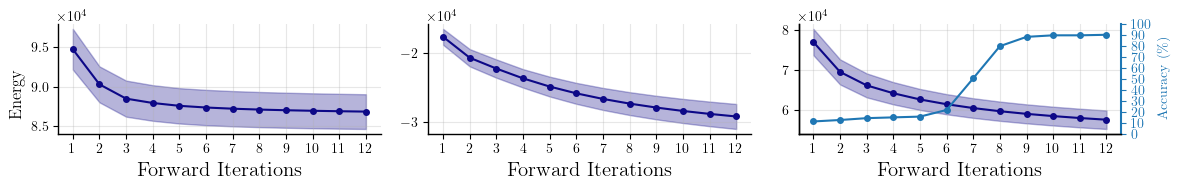

In [5]:
plot_dataset({"Ours": dataset}, "energy")

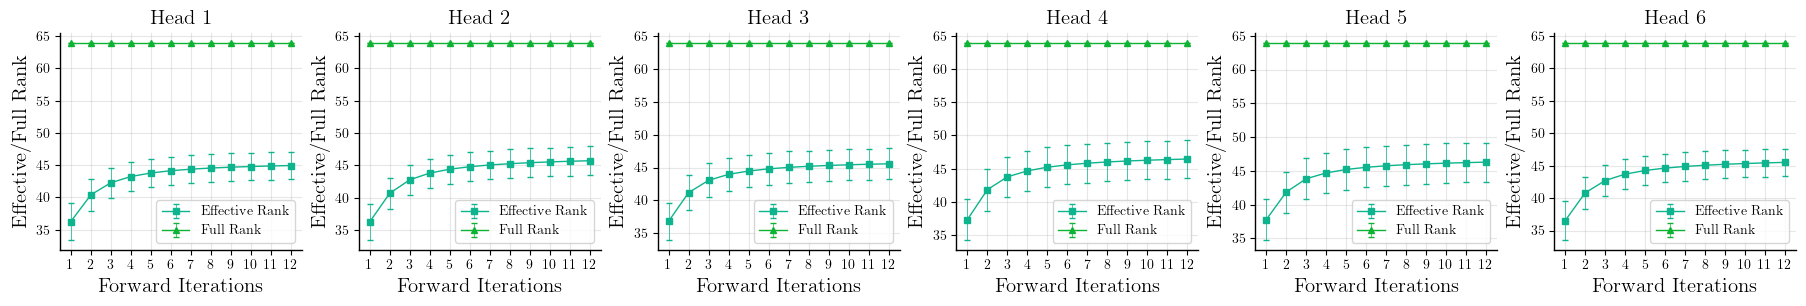

In [6]:
plot_dataset({"Ours": dataset}, "rank")

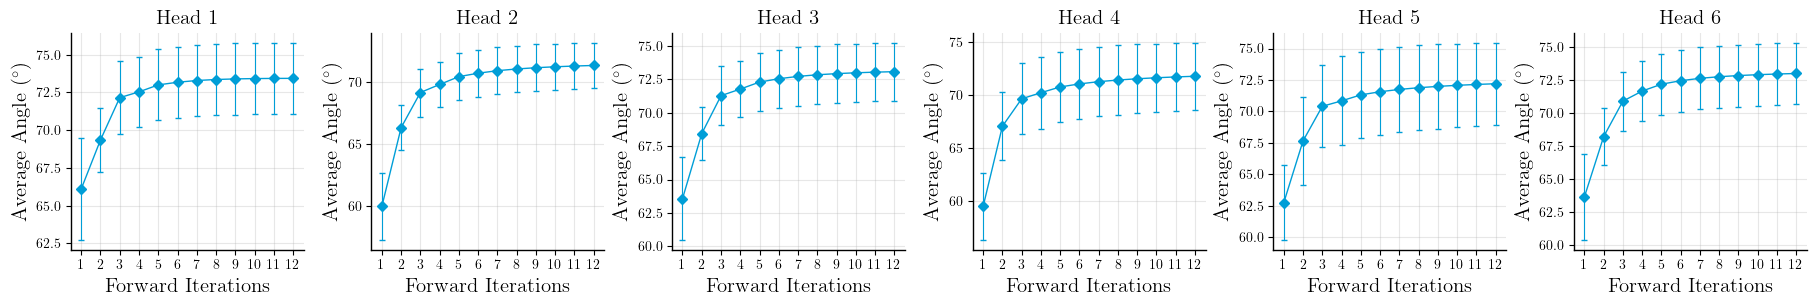

In [7]:
plot_dataset({"Ours": dataset}, "angle")

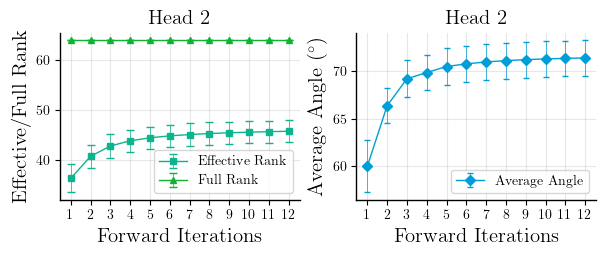

In [8]:
plot_dataset({"Ours": dataset}, "rank_angle")

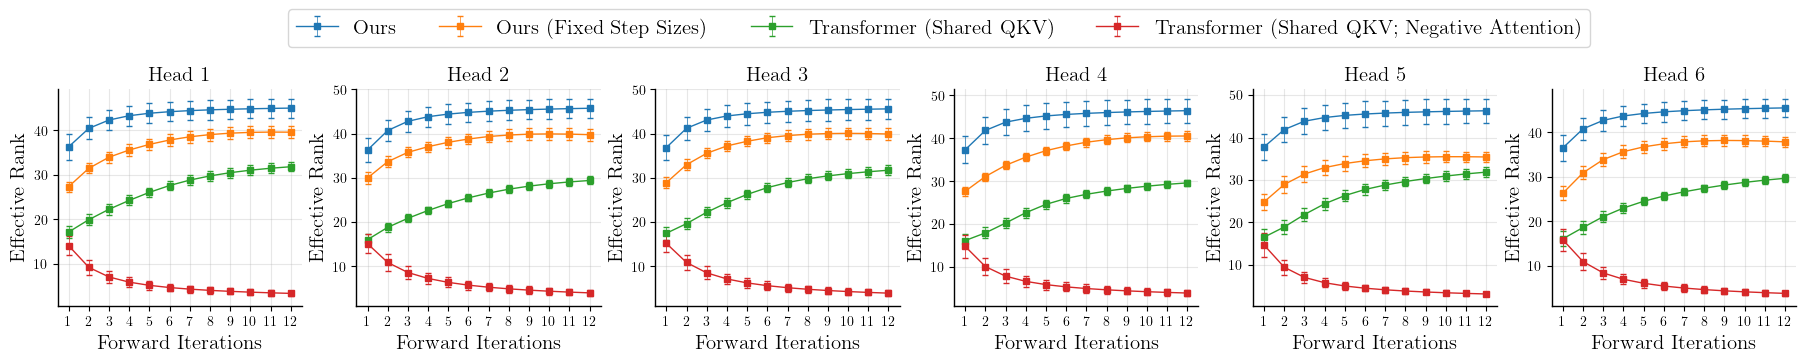

In [ ]:
plot_dataset(
    {
        "Ours": dataset,
        "Ours (Fixed Step Sizes)": fixed_step_dataset,
        "Transformer (Shared QKV)": vit_dataset,
        "Transformer (Shared QKV; Negative Attention)": vit_negative_dataset,
    },
    "rank",
)

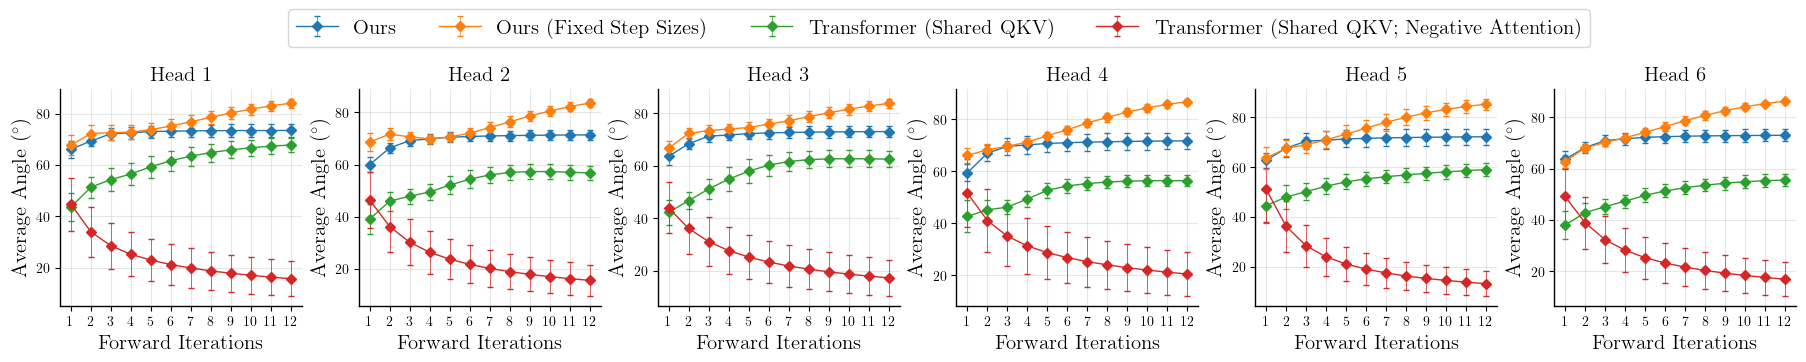

In [ ]:
plot_dataset(
    {
        "Ours": dataset,
        "Ours (Fixed Step Sizes)": fixed_step_dataset,
        "Transformer (Shared QKV)": vit_dataset,
        "Transformer (Shared QKV; Negative Attention)": vit_negative_dataset,
    },
    "angle",
)